# TP 1 : implémentation des concepts de base sur les graphes

Dans ce TP, l'objectif est d'implémenter les opérations simples sur les graphes orientés. 

La représentation choisie pour les graphes est une matrice d'adjacence, qui sera représentée par une matrice `numpy` (les noms des sommets sont des entiers et seront numérotés en commençant à 0). Nous considérons que le nombre de sommets du graphe ne pourra pas être modifié une fois le graphe construit.

### Import des modules utiles

In [13]:
%pip install numpy
import numpy as np

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Définition des fonctions pour la visualisation des graphes (cellules de code données --> rien à compléter)

### Installation de graphviz pour pouvoir visualiser les graphes

In [14]:

%pip install graphviz
import graphviz
graphviz.__version__, graphviz.version()

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


('0.21', (12, 2, 1))

### Création d'une fonction de conversion d'un graphe, défini par une matrice d'adjacence, vers le format graphviz

In [15]:
def creation_graphe_graphviz(g):
    # création d'un graphe orienté
    dot = graphviz.Digraph()
    
    # ajout des sommets
    for i in range(len(g)):
        dot.node(str(i))
    
    # ajout des arcs
    for i in range(len(g)):
        for j in range(len(g)):
            if g[i][j] == 1:
                dot.edge(str(i), str(j))
    

    
    return dot

### Création et affichage d'un premier graphe orienté

In [16]:
graphe1 = np.array([[0,1,1],
          [1,0,1],
          [1,0,0]])

#### Affichage de la matrice

In [17]:
print(graphe1)

[[0 1 1]
 [1 0 1]
 [1 0 0]]


#### Création du graphe associé, au format graphviz, pour pouvoir faire l'affichage de la représentation sagittale du graphe

In [18]:
gdot1 = creation_graphe_graphviz(graphe1)
#print(gdot1.source)

#### Affichage de la représentation sagittale du graphe

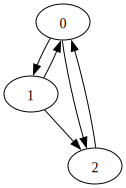

In [19]:
gdot1

### Définition de fonctions pour vérifier des tests sur les fonctions implémentées

In [20]:
def verifie_resultat(res_trouve, res_attendu):
    if res_trouve == res_attendu:
        return " --> resultat ok"
    else:
        return " --> erreur"

In [21]:
def verifie_resultat_matrice(res_trouve, res_attendu):
    if np.array_equal(res_trouve, res_attendu):
        return " --> resultat ok"
    else:
        return " --> erreur"

## Implémentation des premières fonctions pour manipuler les graphes (cellules de code à compléter)

### Déclaration des graphes pour les tests

In [22]:
graphe1 = np.array([[0,1,1],
          [1,0,1],
          [1,0,0]])

### Premières définitions

#### `graphe_vide(n)`: fonction qui construit un graphe vide (sans arcs), avec `n` sommets, et qui retourne la matrice d'adjacence correspondante

In [23]:
def graphe_vide(n):
    return np.zeros((n, n))

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


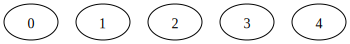

In [24]:
# test de la fonction graphe_vide
graphe2 = graphe_vide(5)
print(graphe2)
gdot2 = creation_graphe_graphviz(graphe2)
gdot2

#### `est_arc(g, i, j)` : fonction qui retourne vrai si l'arc `(i,j)` existe dans le graphe `g`

In [25]:
def est_arc(g, i, j):
    return g[i][j] == 1

In [26]:
# test de la fonction est_arc
print("arc (0, 0) présent dans graphe1 ?", est_arc(graphe1, 0, 0), verifie_resultat(est_arc(graphe1, 0, 0), False)) #faux
print("arc (0, 1) présent dans graphe1 ?", est_arc(graphe1, 0, 1), verifie_resultat(est_arc(graphe1, 0, 1), True)) #vrai

arc (0, 0) présent dans graphe1 ? False  --> resultat ok
arc (0, 1) présent dans graphe1 ? True  --> resultat ok


#### `ajoute_arc(g, i, j)` : fonction qui ajoute l'arc `(i,j)` au graphe `g`, s'il n'est pas déjà présent

In [27]:
def ajoute_arc(g, i, j):
    g[i][j] = 1

In [28]:
# test de la fonction ajoute_arc
graphe1 = np.array([[0,1,1],
          [1,0,1],
          [1,0,0]])
print("arc (0, 0) présent dansz graphe1 ?", est_arc(graphe1, 0, 0), verifie_resultat(est_arc(graphe1, 0, 0), False)) #faux

ajoute_arc(graphe1, 0, 0)
print("arc (0, 0) présent dans graphe1 ?", est_arc(graphe1, 0, 0), verifie_resultat(est_arc(graphe1, 0, 0), True)) #vrai

# réinitialisation de graphe1
graphe1 = np.array([[0,1,1],
          [1,0,1],
          [1,0,0]])


arc (0, 0) présent dansz graphe1 ? False  --> resultat ok
arc (0, 0) présent dans graphe1 ? True  --> resultat ok


In [29]:
# test de la fonction ajoute_arc
graphe1 = np.array([[0,1,1],
          [1,0,1],
          [1,0,0]])
print("arc (0, 1) présent dans graphe1 ?", est_arc(graphe1, 0, 1), verifie_resultat(est_arc(graphe1, 0, 1), True)) #vrai

ajoute_arc(graphe1, 0, 1)
print("arc (0, 1) présent dans graphe1 ?", est_arc(graphe1, 0, 1), verifie_resultat(est_arc(graphe1, 0, 1), True)) #vrai

# réinitialisation de graphe1
graphe1 = np.array([[0,1,1],
          [1,0,1],
          [1,0,0]])


arc (0, 1) présent dans graphe1 ? True  --> resultat ok
arc (0, 1) présent dans graphe1 ? True  --> resultat ok


#### `ote_arc(g, i, j)`: fonction qui ote l'arc `(i,j)` du graphe `g`, s'il était déjà présent

In [30]:
def ote_arc(g, i, j):
    g[i][j] = 0

In [31]:
# test de la fonction ote_arc
graphe1 = np.array([[0,1,1],
          [1,0,1],
          [1,0,0]])
print("arc (1, 1) présent dans graphe1 ?", est_arc(graphe1, 1, 1), verifie_resultat(est_arc(graphe1, 1, 1), False)) #faux

ote_arc(graphe1, 1, 1)
print("arc (1, 1) présent dans graphe1 ?", est_arc(graphe1, 1, 1), verifie_resultat(est_arc(graphe1, 1, 1), False)) #faux

# réinitialisation de graphe1
graphe1 = np.array([[0,1,1],
          [1,0,1],
          [1,0,0]])


arc (1, 1) présent dans graphe1 ? False  --> resultat ok
arc (1, 1) présent dans graphe1 ? False  --> resultat ok


#### `nb_sommets(g)` : fonction qui retourne le nombre de sommets du graphe `g`

In [32]:
def nb_sommets(g):
    return len(g)

In [33]:
# test de la fonction nb_sommets
n = nb_sommets(graphe1)
print("Nombre de sommets de graphe1 :", n, verifie_resultat(n, 3)) #3 

Nombre de sommets de graphe1 : 3  --> resultat ok


### Prédécesseurs et successeurs

#### `successeur(g,s1,s2)` : fonction qui retourne vrai si le sommet `s1` est un successeur du sommet `s2`, dans le graphe `g` et faux sinon

In [39]:
def successeur(g,s1,s2):
    if g[s2][s1] == 1:
        return True
    return False

0 successeur du sommet 0 ? False  --> resultat ok
2 successeur du sommet 1 ? False  --> erreur
0 successeur du sommet 1 ? True  --> resultat ok


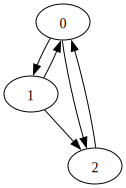

In [38]:
# test de la fonction successeur
print("0 successeur du sommet 0 ?", successeur(graphe1,0,0), verifie_resultat(successeur(graphe1,0,0), False)) #faux
print("2 successeur du sommet 1 ?", successeur(graphe1,2,1), verifie_resultat(successeur(graphe1,2,1), True)) #vrai
print("0 successeur du sommet 1 ?", successeur(graphe1,0,1), verifie_resultat(successeur(graphe1,0,1), True)) #vrai

gdot1

#### `successeurs(g,s)` : fonction qui retourne un tableau numpy contenant les noms des sommets successeurs du sommet `s`, dans le graphe `g`

In [46]:
def successeurs(g,s):
    tab = list()
    for i in range(len(g)): 
        if g[s][i] == 1 :
            tab.append(i)
    return tab 

Successeurs du sommet 0 : [1, 2]  --> resultat ok
Successeurs du sommet 1 : [0, 2]  --> resultat ok
Successeurs du sommet 2 : [0]  --> resultat ok


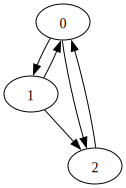

In [47]:
# test de la fonction successeurs
print("Successeurs du sommet 0 :", successeurs(graphe1,0), verifie_resultat_matrice(successeurs(graphe1,0), np.array([1,2]))) #[1,2]
print("Successeurs du sommet 1 :", successeurs(graphe1,1), verifie_resultat_matrice(successeurs(graphe1,1), np.array([0,2]))) #[0,2]
print("Successeurs du sommet 2 :", successeurs(graphe1,2), verifie_resultat_matrice(successeurs(graphe1,2), np.array([0]))) #[0]

gdot1

#### `predecesseur(g,s1,s2)` : fonction qui retourne vrai si le sommet `s1` est un prédécesseur du sommet `s2`, dans le graphe `g`, et faux sinon

In [54]:
def predecesseur(g, s1, s2):
    """
    Retourne True si s1 est prédécesseur de s2 dans le graphe g.
    
    g : matrice d'adjacence
    s1 : sommet candidat
    s2 : sommet dont on teste le prédécesseur
    """
    return g[s1][s2] == 1


0 prédécesseur du sommet 0 ? False  --> resultat ok
1 prédécesseur du sommet 2 ? True  --> resultat ok
0 prédécesseur du sommet 1 ? True  --> resultat ok


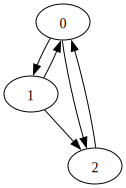

In [55]:
# test de la fonction predecesseur
print("0 prédécesseur du sommet 0 ?", predecesseur(graphe1,0,0), verifie_resultat(predecesseur(graphe1,0,0), False)) #faux
print("1 prédécesseur du sommet 2 ?", predecesseur(graphe1,1,2), verifie_resultat(predecesseur(graphe1,1,2), True)) #vrai
print("0 prédécesseur du sommet 1 ?", predecesseur(graphe1,0,1), verifie_resultat(predecesseur(graphe1,0,1), True)) #vrai

gdot1

#### `predecesseurs(g,s)` : fonction qui retourne un tableau contenant les noms des sommets prédécesseurs du sommet `s`, dans le graphe `g`

In [58]:
def predecesseurs(g,s):
    tab = list()
    for i in range(len(g)): 
        if g[i][s] == 1 :
            tab.append(i)
    return tab 

Prédécesseurs du sommet 0 : [1, 2]  --> resultat ok
Prédécesseurs du sommet 1 : [0]  --> resultat ok
Prédécesseurs du sommet 2 : [0, 1]  --> resultat ok


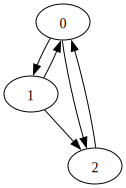

In [59]:
# test de la fonction predecesseurs
print("Prédécesseurs du sommet 0 :", predecesseurs(graphe1,0), verifie_resultat(predecesseurs(graphe1,0), [1,2])) #[1,2]
print("Prédécesseurs du sommet 1 :", predecesseurs(graphe1,1), verifie_resultat(predecesseurs(graphe1,1), [0])) #[0]
print("Prédécesseurs du sommet 2 :", predecesseurs(graphe1,2), verifie_resultat(predecesseurs(graphe1,2), [0,1])) #[0,1]

gdot1

### Degrés d'un sommet

#### `degre_entrant(g, s)` : fonction qui retourne le degré entrant du sommet `s`, dans le graphe `g`

In [62]:
def degre_entrant(g, s):
    tab = []
    for i in range(len(g)): 
        if g[i][s] == 1 :
            tab.append(i)
    return len(tab) 

Degré entrant du sommet 0 : 2  --> resultat ok
Degré entrant du sommet 1 : 1  --> resultat ok
Degré entrant du sommet 2 : 2  --> resultat ok


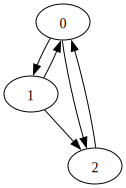

In [63]:
# test de la fonction degre_entrant
print("Degré entrant du sommet 0 :", degre_entrant(graphe1,0), verifie_resultat(degre_entrant(graphe1,0), 2)) #2
print("Degré entrant du sommet 1 :", degre_entrant(graphe1,1), verifie_resultat(degre_entrant(graphe1,1), 1)) #1
print("Degré entrant du sommet 2 :", degre_entrant(graphe1,2), verifie_resultat(degre_entrant(graphe1,2), 2)) #2

gdot1

#### `degre_sortant(g, s)` : fonction qui retourne le degré sortant du sommet `s`, dans le graphe `g`

In [64]:
def degre_sortant(g, s):
    tab = []
    for i in range(len(g)): 
        if g[s][i] == 1 :
            tab.append(i)
    return len(tab) 

Degré sortant du sommet 0 : 2  --> resultat ok
Degré sortant du sommet 1 : 2  --> resultat ok
Degré sortant du sommet 2 : 1  --> resultat ok


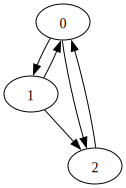

In [65]:
# test de la fonction degre_sortant
print("Degré sortant du sommet 0 :", degre_sortant(graphe1,0), verifie_resultat(degre_sortant(graphe1,0), 2))
print("Degré sortant du sommet 1 :", degre_sortant(graphe1,1), verifie_resultat(degre_sortant(graphe1,1), 2))
print("Degré sortant du sommet 2 :", degre_sortant(graphe1,2), verifie_resultat(degre_sortant(graphe1,2), 1))

gdot1

#### `degre_total(g, s)` : fonction qui retourne le degré total du sommet `s`, dans le graphe `g`

In [66]:
def degre_total(g, s):
    tab1 = []
    for i in range(len(g)): 
        if g[i][s] == 1 :
            tab1.append(i)
    tab2 = []
    for i in range(len(g)): 
        if g[s][i] == 1 :
            tab2.append(i)
    return len(tab1+tab2)

In [67]:
# test de la fonction degre_total
print("Degré total du sommet 0 :", degre_total(graphe1,0), verifie_resultat(degre_total(graphe1,0), 4))
print("Degré total du sommet 1 :", degre_total(graphe1,1), verifie_resultat(degre_total(graphe1,1), 3))
print("Degré total du sommet 2 :", degre_total(graphe1,2), verifie_resultat(degre_total(graphe1,2), 3))

Degré total du sommet 0 : 4  --> resultat ok
Degré total du sommet 1 : 3  --> resultat ok
Degré total du sommet 2 : 3  --> resultat ok


### Sommets source et puits

#### `est_source(g, s)` : fonction qui retourne vrai si le sommet `s` est une source, dans le graphe `g`

In [68]:
def est_source(g, s):
    for i in range(len(g)):
        if g[i][s] == 1:
            return False  # un prédécesseur = pas source source
    return True  # aucun prédécesseur = source

In [69]:
# test de la fonction est_source
print("Sommet 0 source de graphe1 ? ", est_source(graphe1,0), verifie_resultat(est_source(graphe1,0), False))
print("Sommet 0 source de graphe2 ? ", est_source(graphe2,0), verifie_resultat(est_source(graphe2,0), True))

Sommet 0 source de graphe1 ?  False  --> resultat ok
Sommet 0 source de graphe2 ?  True  --> resultat ok


#### `est_puits(g, s)` : fonction qui retourne vrai si le sommet `s` est un puits, dans le graphe `g`

In [72]:
def est_puits(g, s):
    for i in range(len(g)):
        if g[s][i] == 1:
            return False  # aucun prédécesseur = puit
    return True  # prédécesseur = pas puit

In [73]:
# test de la fonction est_puits
print("Sommet 0 puits de graphe1 ? ", est_puits(graphe1,0), verifie_resultat(est_puits(graphe1,0), False))
print("Sommet 0 puits de graphe2 ? ", est_puits(graphe2,0), verifie_resultat(est_puits(graphe2,0), True))


Sommet 0 puits de graphe1 ?  False  --> resultat ok
Sommet 0 puits de graphe2 ?  True  --> resultat ok


## Implémentation des fonctions bonus (cellules de code à compléter)

### Degrés des sommets du graphe

#### `degres_entrants(g)` : fonction qui retourne les degrés entrants des sommets du graphe `g`, sous la forme d'un tableau numpy

In [ ]:
def degres_entrants(g):
    raise NotImplementedError

In [ ]:
# test de la fonction degres_entrants
print("Degrés entrants des sommets de graphe1 :", degres_entrants(graphe1), verifie_resultat_matrice(degres_entrants(graphe1), np.array([2,1,2])))

#### `degres_sortants(g)` : fonction qui retourne les degrés sortants des sommets du graphe `g`, sous la forme d'un tableau numpy

In [ ]:
def degres_sortants(g):
    raise NotImplementedError

In [ ]:
# test de la fonction degres_sortants
print("Degrés sortants des sommets de graphe1 :", degres_sortants(graphe1), verifie_resultat_matrice(degres_sortants(graphe1), np.array([2,2,1])))

#### `degres_totaux(g)` : fonction qui retourne les degrés totaux des sommets du graphe `g`, sous la forme d'un tableau numpy

In [ ]:
def degres_totaux(g):
    raise NotImplementedError

In [ ]:
print("Degrés totaux des sommets de graphe1 :", degres_totaux(graphe1), verifie_resultat_matrice(degres_totaux(graphe1), np.array([4,3,3])))

### Identification de graphes particuliers

#### `est_simple(g)` : fonction qui indique si le graphe `g` est simple

In [ ]:
def est_simple(g):
    raise NotImplementedError

In [ ]:
# test de la fonction est_simple
print("graphe1 simple ?", est_simple(graphe1), verifie_resultat(est_simple(graphe1), True)) #vrai

#### `est_complet(g)` : fonction qui indique si le graphe `g` est complet

In [ ]:
def est_complet(g):
    raise NotImplementedError

In [ ]:
# test de la fonction est_complet
print("graphe1 complet ?", est_complet(graphe1), verifie_resultat(est_complet(graphe1), False)) #faux

#### `est_symetrique(g)` : fonction qui indique si le graphe `g` est symétrique

In [ ]:
def est_symetrique(g):
    raise NotImplementedError

In [ ]:
# test de la fonction est_symetrique
print("graphe1 symétrique ?", est_symetrique(graphe1), verifie_resultat(est_symetrique(graphe1), False)) #faux

### Construction de graphes particuliers

#### `graphe_reciproque(g)` : fonction qui retourne la matrice d'adjacence correspondant au graphe réciproque du graphe `g`

In [ ]:
def graphe_reciproque(g):
    raise NotImplementedError

In [ ]:
# test de la fonction graphe_reciproque
graphe1_rec_attendu = np.array([[0,1,1], 
                        [1, 0, 0], 
                        [1, 1, 0]])
graphe1_rec = graphe_reciproque(graphe1)
print("Graphe réciproque de graphe1\n", graphe1_rec, verifie_resultat_matrice(graphe1_rec, graphe1_rec_attendu))

gdot1_rec = creation_graphe_graphviz(graphe1_rec)
gdot1_rec

#### `graphe_complementaire(g)` : fonction qui retourne la matrice d'adjacence correspondant au graphe complémentaire du graphe `g`

In [ ]:
def graphe_complementaire(g):
    raise NotImplementedError

In [ ]:
# test de la fonction graphe_complementaire
graphe1_comp_attendu = np.array([[1, 0, 0], 
                            [0, 1, 0], 
                            [0, 1, 1]])
graphe1_comp = graphe_complementaire(graphe1)
print("Graphe complémentaire de graphe1\n", graphe1_comp, verifie_resultat_matrice(graphe1_comp, graphe1_comp_attendu))


gdot1_comp = creation_graphe_graphviz(graphe1_comp)
gdot1_comp

#### `graphe_symetrique(g)` : fonction qui retourne la matrice d'adjacence correspondant au graphe symétrique du graphe `g`

In [ ]:
def graphe_symetrique(g):
    raise NotImplementedError

In [ ]:
# test de la fonction graphe_symetrique
graphe1_sym_attendu = np.array([[0, 1, 1], 
                            [1, 0, 1], 
                            [1, 1, 0]])
graphe1_sym = graphe_symetrique(graphe1)
print("Graphe symétrique de graphe1\n", graphe1_sym, verifie_resultat_matrice(graphe1_sym, graphe1_sym_attendu))

gdot1_sym = creation_graphe_graphviz(graphe1_sym)
gdot1_sym

### Sous-graphes

#### `est_sous_graphe(g1, g2)` : fonction qui retourne vrai si le graphe `g2` est un sous-graphe du graphe `g1` (`g1` et `g2` doivent avoir le même nombre de sommets)

In [ ]:
def est_sous_graphe(g1, g2):
    raise NotImplementedError

In [ ]:
# test de la fonction est_sous_graphe
ssGraphe1 = [[0,1,0],[0,0,1],[0,0,0]]
print("ssGraphe1 sous-graphe de graphe1 ?", est_sous_graphe(graphe1, ssGraphe1), verifie_resultat(est_sous_graphe(graphe1, ssGraphe1), True))


In [ ]:
# test de la fonction est_sous_graphe
ssGraphe2 = [[0,1,0],[0,0,1],[0,0,1]]
print("ssGraphe2 sous-graphe de graphe1 ?", est_sous_graphe(graphe2, ssGraphe1), verifie_resultat(est_sous_graphe(graphe2, ssGraphe1), False))
